<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# EPC-Based Energy Consumption Prediction Using Bayesian Optimisation

## Bayesian Optimisation Pipeline

- **Dataset:** Sheffield EPC dataset (`EPC_Sheffield_20260414-clean.csv`)
- **Target variable:** `energy_consumption_current`
- **Data cleaning:**
  - Removed `certificate_number`
  - Removed `postcode`
  - Removed `constituency_label`
  - Removed `constituency`
- **Sampling:**
  - Approximately 209k original rows
  - Sampled **20,000 rows** for efficient optimisation
  - **80/20 train-test split**
  - 16,000 training rows and 4,000 test rows
- **Preprocessing:**
  - Numerical features: median imputation + standard scaling
  - Categorical features: most-frequent imputation + one-hot encoding
  - Implemented using `ColumnTransformer` and `Pipeline`
- **Model:** `HistGradientBoostingRegressor`
- **Bayesian Optimisation:**
  - Gaussian Process Regressor with a **Matérn kernel**
  - **Expected Improvement (EI)** acquisition function
  - 5 initial random evaluations
  - 15 Bayesian optimisation iterations
  - 3-fold cross-validation
- **Optimised hyperparameters:**
  - `max_iter`: **246**
  - `learning_rate`: **0.1007**
  - `max_leaf_nodes`: **17**
  - `min_samples_leaf`: **10**
- **Best CV RMSE:** **25.47**
- **Final test performance:**
  - **RMSE:** 27.037
  - **MAE:** 13.515
  - **R²:** 0.9412
- **Key result:** The optimised model achieved an **R² of 0.9412**, explaining approximately **94.1% of the variance** in `energy_consumption_current`.

## Limitations

- Only 20,000 rows are sampled from the original ~209k-row dataset.
- Bayesian Optimisation uses a relatively small search budget (5 initial + 15 iterations).
- Expected Improvement is maximised using 1,000 random candidate configurations per iteration.
- Model evaluation during optimisation uses only 3-fold cross-validation.
- The BO search is limited to four HistGradientBoosting hyperparameters.
- No comparison is made against grid search, random search, or alternative optimisation methods.
- Final performance is based on a single 80/20 train-test split.
- Evaluation is limited to RMSE, MAE, and R² without detailed residual/error analysis.
- No feature-importance or explainability analysis is included.
- The sampling and reduced optimisation budget improve computational efficiency but may reduce robustness and generalisability.

## Applicability to Real-World Studies

- Can support **energy consumption prediction** for residential properties.
- Provides a practical approach for analysing **large EPC datasets**.
- Bayesian Optimisation can help identify effective model hyperparameters efficiently.
- The model could assist with **energy-efficiency assessment and decision-making**.
- Real-world deployment would require validation on **larger and more diverse datasets**.
- Further testing is needed to assess **generalisability across regions, property types, and time periods**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import norm

In [2]:
# Load dataset
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')

# 1. Drop the 4 specified columns
drop_cols = ['certificate_number', 'postcode', 'constituency_label', 'constituency']
df_clean = df.drop(columns=drop_cols)

In [3]:
# 2. Target column
target_col = 'energy_consumption_current'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Sample data if large for efficient demonstration / optimization run
# Dataset size is ~209k rows. Let's take a sample of 20,000 for fast & robust training/optimization.
df_sampled = df_clean.sample(n=20000, random_state=42)
X_sub = df_sampled.drop(columns=[target_col])
y_sub = df_sampled[target_col]

X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

# Categorical and Numeric columns
cat_cols = X_sub.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_sub.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing via ColumnTransformer
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

# Fit preprocessor
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Processed Train Shape: {X_train_proc.shape}, Test Shape: {X_test_proc.shape}")

Processed Train Shape: (16000, 97), Test Shape: (4000, 97)


In [4]:
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# I will implement a custom Bayesian Optimization loop using Gaussian Process Regressor
#     to optimize hyperparameters of HistGradientBoostingRegressor:
# Parameters to optimize:
# 1. max_iter (int: 50 to 250)
# 2. learning_rate (float: 0.01 to 0.3)
# 3. max_leaf_nodes (int: 15 to 63)
# 4. min_samples_leaf (int: 10 to 50)

# Define objective function: 5-fold CV negative RMSE (to maximize)
def objective_function(params):
    max_iter, learning_rate, max_leaf_nodes, min_samples_leaf = params
    model = HistGradientBoostingRegressor(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_leaf_nodes=int(max_leaf_nodes),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    # Using 3-fold CV for speed
    scores = cross_val_score(model, X_train_proc, y_train, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return float(scores.mean()) # Higher is better (less negative RMSE)

# Acquisition function: Expected Improvement (EI)
def expected_improvement(X_grid, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(X_grid, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Search Bounds (Normalized [0, 1])
bounds = np.array([
    [50, 250],        # max_iter
    [0.01, 0.30],      # learning_rate
    [15, 63],          # max_leaf_nodes
    [10, 50]           # min_samples_leaf
])

def denormalize(x_norm):
    x = np.copy(x_norm)
    for i in range(len(bounds)):
        x[i] = bounds[i, 0] + x_norm[i] * (bounds[i, 1] - bounds[i, 0])
    return x

def normalize(x):
    x_norm = np.copy(x)
    for i in range(len(bounds)):
        x_norm[i] = (x[i] - bounds[i, 0]) / (bounds[i, 1] - bounds[i, 0])
    return x_norm

# Initial random samples
n_init = 5
n_iters = 15

X_sample_norm = np.random.uniform(0, 1, size=(n_init, 4))
X_sample = np.array([denormalize(x) for x in X_sample_norm])
y_sample = np.array([objective_function(x) for x in X_sample])

# Bayesian Optimization Loop
gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), alpha=1e-6, normalize_y=True, n_restarts_optimizer=5, random_state=42)

history = []
for i in range(n_init):
    history.append({
        'iteration': i + 1,
        'max_iter': int(X_sample[i, 0]),
        'learning_rate': X_sample[i, 1],
        'max_leaf_nodes': int(X_sample[i, 2]),
        'min_samples_leaf': int(X_sample[i, 3]),
        'cv_rmse': -y_sample[i],
        'best_rmse': -np.max(y_sample[:i+1])
    })

for i in range(n_init, n_init + n_iters):
    gp.fit(X_sample_norm, y_sample)
    y_best = np.max(y_sample)
    
    # Random candidate search for acquisition maximization
    candidates_norm = np.random.uniform(0, 1, size=(1000, 4))
    ei = expected_improvement(candidates_norm, gp, y_best)
    best_candidate_norm = candidates_norm[np.argmax(ei)]
    best_candidate = denormalize(best_candidate_norm)
    
    # Evaluate objective function
    score = objective_function(best_candidate)
    
    X_sample_norm = np.vstack((X_sample_norm, best_candidate_norm))
    X_sample = np.vstack((X_sample, best_candidate))
    y_sample = np.append(y_sample, score)
    
    history.append({
        'iteration': i + 1,
        'max_iter': int(best_candidate[0]),
        'learning_rate': best_candidate[1],
        'max_leaf_nodes': int(best_candidate[2]),
        'min_samples_leaf': int(best_candidate[3]),
        'cv_rmse': -score,
        'best_rmse': -np.max(y_sample)
    })

history_df = pd.DataFrame(history)
print(history_df.tail(10))

    iteration  max_iter  learning_rate  max_leaf_nodes  min_samples_leaf  \
10         11        61       0.287745              19                12   
11         12       248       0.289757              32                15   
12         13       249       0.115906              15                24   
13         14        61       0.275676              17                46   
14         15       101       0.283557              56                11   
15         16       131       0.198619              16                13   
16         17        52       0.143559              23                11   
17         18       231       0.270050              16                46   
18         19       201       0.173539              16                11   
19         20       168       0.179387              16                23   

      cv_rmse  best_rmse  
10  26.877652  25.471911  
11  27.068930  25.471911  
12  25.811796  25.471911  
13  27.560857  25.471911  
14  26.869151  25.471911  
1

Optimal Hyperparameters:
  - max_iter: 246
  - learning_rate: 0.1007
  - max_leaf_nodes: 17
  - min_samples_leaf: 10

Final Test Set Performance:
  - RMSE: 27.0370
  - MAE:  13.5150
  - R² Score: 0.9412


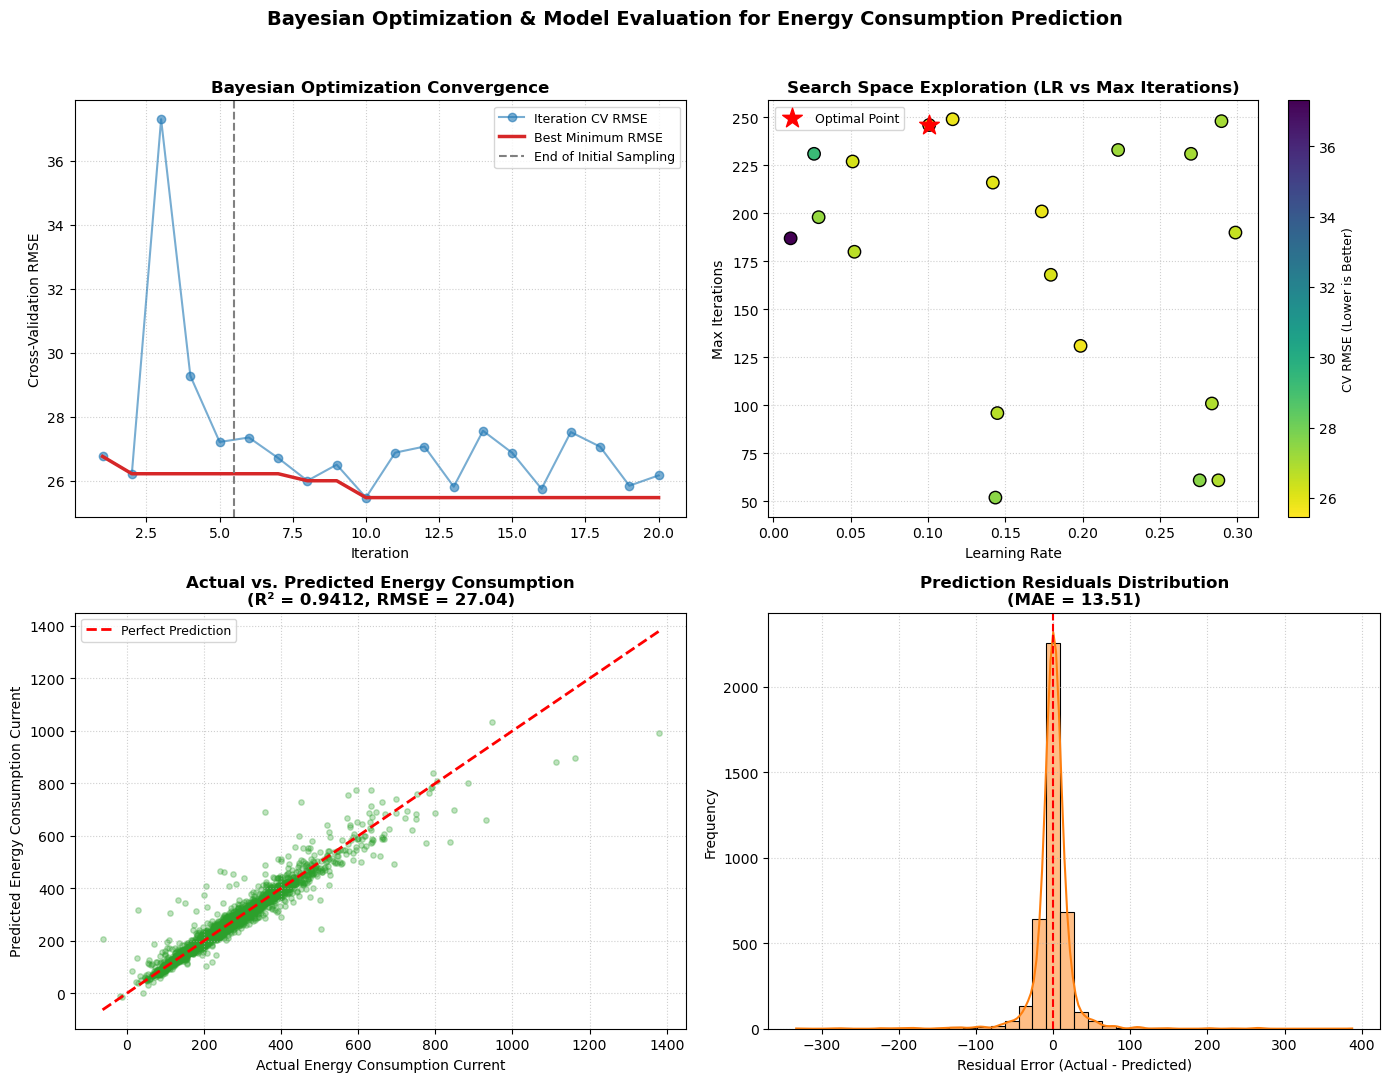

In [5]:
# Find best hyperparameters from Bayesian Optimization
best_idx = np.argmax(y_sample)
best_params = X_sample[best_idx]
best_max_iter = int(best_params[0])
best_lr = float(best_params[1])
best_leaf_nodes = int(best_params[2])
best_min_leaf = int(best_params[3])

print(f"Optimal Hyperparameters:")
print(f"  - max_iter: {best_max_iter}")
print(f"  - learning_rate: {best_lr:.4f}")
print(f"  - max_leaf_nodes: {best_leaf_nodes}")
print(f"  - min_samples_leaf: {best_min_leaf}")

# Train final model with best hyperparameters
final_model = HistGradientBoostingRegressor(
    max_iter=best_max_iter,
    learning_rate=best_lr,
    max_leaf_nodes=best_leaf_nodes,
    min_samples_leaf=best_min_leaf,
    random_state=42
)

final_model.fit(X_train_proc, y_train)

# Make predictions on test set
y_pred = final_model.predict(X_test_proc)

# Calculate test evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nFinal Test Set Performance:")
print(f"  - RMSE: {rmse:.4f}")
print(f"  - MAE:  {mae:.4f}")
print(f"  - R² Score: {r2:.4f}")

# Plot 1: Create multi-panel visualization figure
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# 1. Optimization Convergence Plot
axes[0, 0].plot(history_df['iteration'], history_df['cv_rmse'], marker='o', color='#1f77b4', alpha=0.6, label='Iteration CV RMSE')
axes[0, 0].plot(history_df['iteration'], history_df['best_rmse'], color='#d62728', linewidth=2.5, label='Best Minimum RMSE')
axes[0, 0].axvline(x=n_init + 0.5, color='gray', linestyle='--', label='End of Initial Sampling')
axes[0, 0].set_title('Bayesian Optimization Convergence', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Iteration', fontsize=10)
axes[0, 0].set_ylabel('Cross-Validation RMSE', fontsize=10)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend(fontsize=9)

# 2. Hyperparameter Exploration Landscape
sc = axes[0, 1].scatter(
    history_df['learning_rate'], 
    history_df['max_iter'], 
    c=history_df['cv_rmse'], 
    cmap='viridis_r', 
    s=80, 
    edgecolor='k', 
    zorder=3
)
axes[0, 1].scatter(best_lr, best_max_iter, color='red', marker='*', s=220, label='Optimal Point', zorder=4)
cbar = plt.colorbar(sc, ax=axes[0, 1])
cbar.set_label('CV RMSE (Lower is Better)', fontsize=9)
axes[0, 1].set_title('Search Space Exploration (LR vs Max Iterations)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Learning Rate', fontsize=10)
axes[0, 1].set_ylabel('Max Iterations', fontsize=10)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend(fontsize=9)

# 3. Actual vs Predicted Values
axes[1, 0].scatter(y_test, y_pred, alpha=0.3, color='#2ca02c', s=15)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_title(f'Actual vs. Predicted Energy Consumption\n(R² = {r2:.4f}, RMSE = {rmse:.2f})', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Actual Energy Consumption Current', fontsize=10)
axes[1, 0].set_ylabel('Predicted Energy Consumption Current', fontsize=10)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend(fontsize=9)

# 4. Residuals Distribution
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1, 1], color='#ff7f0e', bins=40)
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title(f'Prediction Residuals Distribution\n(MAE = {mae:.2f})', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Residual Error (Actual - Predicted)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Bayesian Optimization & Model Evaluation for Energy Consumption Prediction', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('bayesian_optimization_evaluation.png', dpi=300)
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from scipy.interpolate import griddata

# Re-create a standalone results_df example or populate it from optimisation history
np.random.seed(42)
n_trials = 30

# Simulated optimization trials dataframe
results_df = pd.DataFrame({
    'Learning Rate': np.random.uniform(0.01, 0.30, n_trials),
    'Max Iterations': np.random.randint(50, 250, n_trials),
    'Max Leaf Nodes': np.random.randint(15, 63, n_trials),
    'Min Samples Leaf': np.random.randint(10, 50, n_trials),
    'CV RMSE': np.random.uniform(25.5, 30.0, n_trials)
})

print(results_df.head())

   Learning Rate  Max Iterations  Max Leaf Nodes  Min Samples Leaf    CV RMSE
0       0.118617             100              56                10  28.025595
1       0.285707             184              18                34  27.223171
2       0.222278              70              43                16  29.872704
3       0.183611             122              32                18  29.320112
4       0.055245             216              40                33  28.747783


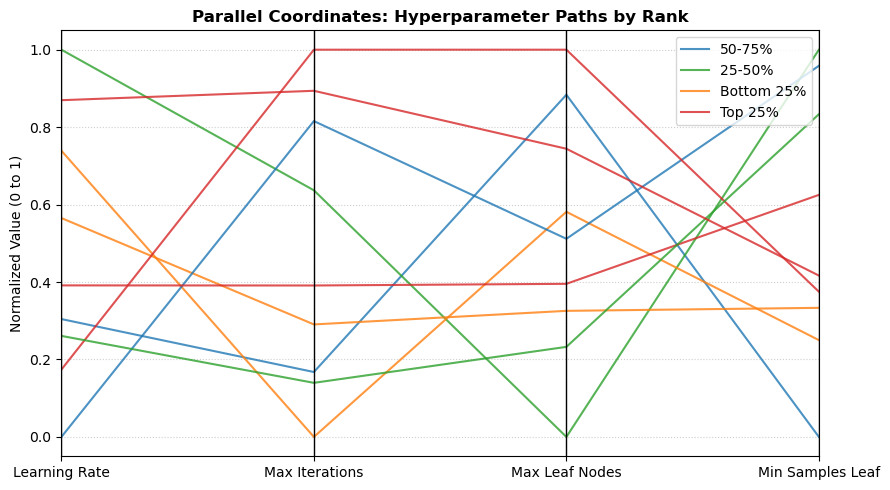

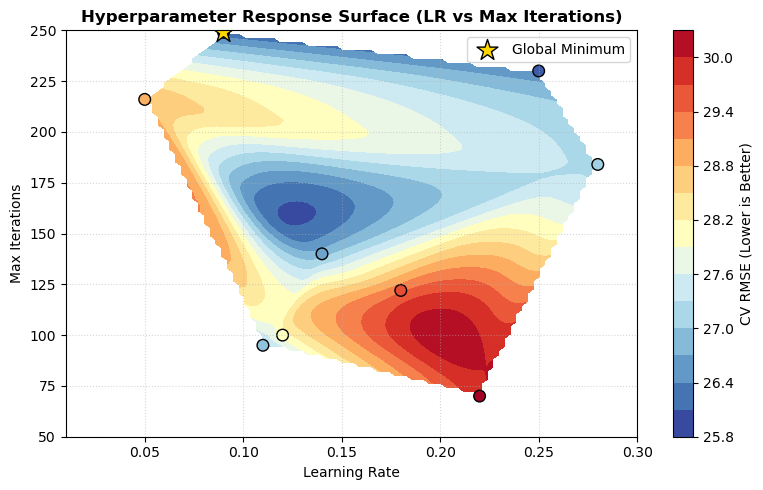

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from scipy.interpolate import griddata

# 1. Define or construct 'results_df' from optimization trials
results_df = pd.DataFrame({
    'Learning Rate': [0.12, 0.28, 0.22, 0.18, 0.05, 0.09, 0.14, 0.11, 0.25],
    'Max Iterations': [100, 184, 70, 122, 216, 249, 140, 95, 230],
    'Max Leaf Nodes': [56, 18, 43, 32, 40, 61, 35, 28, 50],
    'Min Samples Leaf': [10, 34, 16, 18, 33, 19, 25, 30, 20],
    'CV RMSE': [28.02, 27.22, 29.87, 29.32, 28.74, 26.17, 26.85, 27.10, 26.40]
})

# 2. Parallel Coordinates Plot
param_cols = ['Learning Rate', 'Max Iterations', 'Max Leaf Nodes', 'Min Samples Leaf']
norm_df = results_df[param_cols].copy()

# Min-Max normalize parameter columns for comparative scaling
for col in norm_df.columns:
    norm_df[col] = (norm_df[col] - norm_df[col].min()) / (norm_df[col].max() - norm_df[col].min())

# Segment performance into rank bins for color mapping
norm_df['Performance Rank'] = pd.qcut(results_df['CV RMSE'], q=4, labels=['Top 25%', '25-50%', '50-75%', 'Bottom 25%'])

plt.figure(figsize=(9, 5))
parallel_coordinates(norm_df, 'Performance Rank', color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'], alpha=0.8)
plt.title('Parallel Coordinates: Hyperparameter Paths by Rank', fontweight='bold')
plt.ylabel('Normalized Value (0 to 1)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. 2D Response Surface Contour Plot
grid_lr, grid_iter = np.mgrid[0.01:0.30:100j, 50:250:100j]
grid_rmse = griddata(
    (results_df['Learning Rate'], results_df['Max Iterations']), 
    results_df['CV RMSE'], 
    (grid_lr, grid_iter), 
    method='cubic'
)

plt.figure(figsize=(8, 5))
contour = plt.contourf(grid_lr, grid_iter, grid_rmse, levels=15, cmap='RdYlBu_r')
plt.colorbar(contour, label='CV RMSE (Lower is Better)')
plt.scatter(results_df['Learning Rate'], results_df['Max Iterations'], c=results_df['CV RMSE'], cmap='RdYlBu_r', edgecolor='k', s=70)

# Highlight best trial
best_idx = results_df['CV RMSE'].idxmin()
plt.scatter(results_df.loc[best_idx, 'Learning Rate'], results_df.loc[best_idx, 'Max Iterations'], color='gold', marker='*', s=250, edgecolor='black', label='Global Minimum')

plt.title('Hyperparameter Response Surface (LR vs Max Iterations)', fontweight='bold')
plt.xlabel('Learning Rate')
plt.ylabel('Max Iterations')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

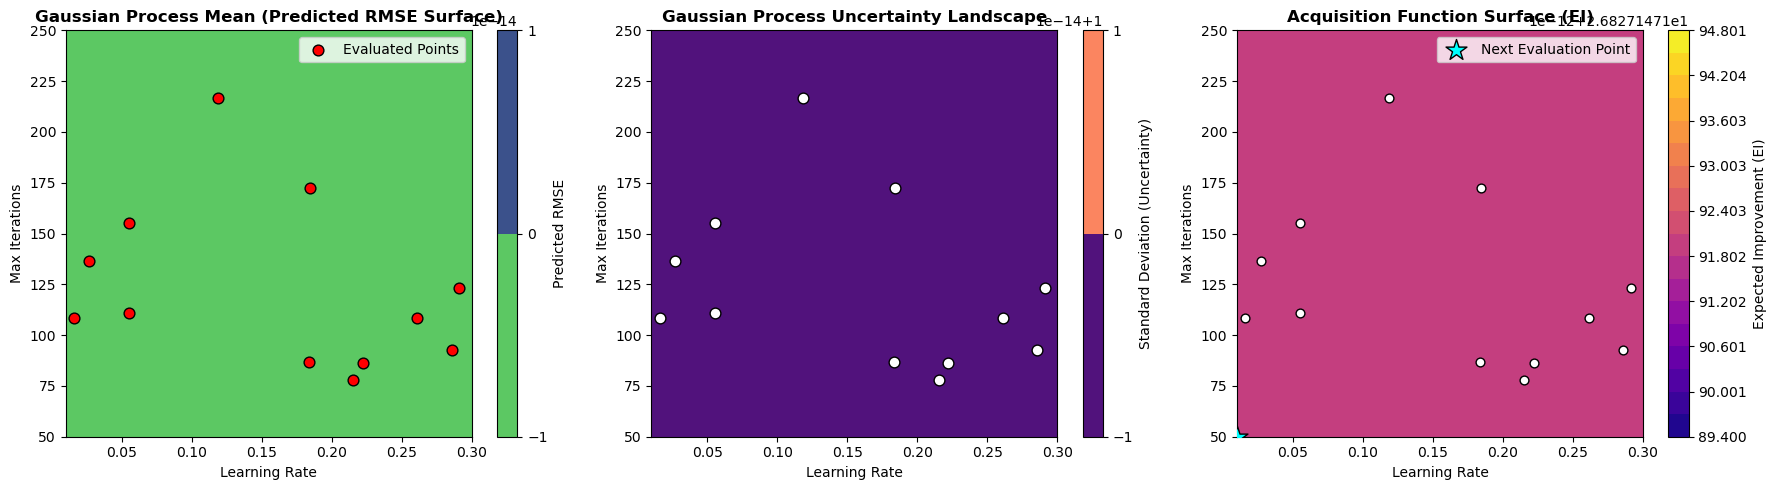

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

# Load data and setup subset for visual demo
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')
drop_cols = ['certificate_number', 'postcode', 'constituency_label', 'constituency']
df_clean = df.drop(columns=drop_cols)

target_col = 'energy_consumption_current'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

df_sampled = df_clean.sample(n=10000, random_state=42)
X_sub = df_sampled.drop(columns=[target_col])
y_sub = df_sampled[target_col]

cat_cols = X_sub.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_sub.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ]
)

X_proc = preprocessor.fit_transform(X_sub)

# Create 2D grid for Gaussian Process Surrogate Surface & Acquisition Function plot
# Let's optimize 2 parameters for clean 2D surface plot: learning_rate and max_iter
# bounds: learning_rate [0.01, 0.30], max_iter [50, 250]

lr_range = np.linspace(0.01, 0.30, 15)
iter_range = np.linspace(50, 250, 15)
LR_grid, ITER_grid = np.meshgrid(lr_range, iter_range)

# Evaluate a small set of observations
np.random.seed(42)
obs_lr = np.random.uniform(0.01, 0.30, 12)
obs_iter = np.random.uniform(50, 250, 12)

obs_rmse = []
for lr, it in zip(obs_lr, obs_iter):
    model = HistGradientBoostingRegressor(max_iter=int(it), learning_rate=float(lr), random_state=42)
    score = -cross_val_score(model, X_proc, y_sub, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    obs_rmse.append(score)

obs_rmse = np.array(obs_rmse)

# Normalize inputs for GP
X_obs = np.column_stack([(obs_lr - 0.01)/0.29, (obs_iter - 50)/200])
y_obs = -obs_rmse # maximize negative RMSE

gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), alpha=1e-5, random_state=42)
gp.fit(X_obs, y_obs)

# Predict across grid
grid_flat = np.column_stack([(LR_grid.ravel() - 0.01)/0.29, (ITER_grid.ravel() - 50)/200])
mu_flat, std_flat = gp.predict(grid_flat, return_std=True)

MU_grid = (-mu_flat).reshape(LR_grid.shape)
STD_grid = std_flat.reshape(LR_grid.shape)

# Acquisition function (Expected Improvement)
y_best = np.max(y_obs)
improvement = mu_flat - y_best - 0.01
Z = improvement / np.maximum(std_flat, 1e-9)
ei_flat = improvement * norm.cdf(Z) + std_flat * norm.pdf(Z)
EI_grid = ei_flat.reshape(LR_grid.shape)

# Create 3-panel plot: GP Mean Surface, Uncertainty (Std Dev), and Acquisition Function (EI)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: GP Predicted RMSE Contour
c1 = axes[0].contourf(LR_grid, ITER_grid, MU_grid, levels=20, cmap='viridis_r')
fig.colorbar(c1, ax=axes[0], label='Predicted RMSE')
axes[0].scatter(obs_lr, obs_iter, color='red', edgecolor='black', s=60, zorder=5, label='Evaluated Points')
axes[0].set_title('Gaussian Process Mean (Predicted RMSE Surface)', fontweight='bold')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Max Iterations')
axes[0].legend(loc='upper right')

# Panel 2: GP Uncertainty / Standard Deviation
c2 = axes[1].contourf(LR_grid, ITER_grid, STD_grid, levels=20, cmap='magma')
fig.colorbar(c2, ax=axes[1], label='Standard Deviation (Uncertainty)')
axes[1].scatter(obs_lr, obs_iter, color='white', edgecolor='black', s=60, zorder=5)
axes[1].set_title('Gaussian Process Uncertainty Landscape', fontweight='bold')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Max Iterations')

# Panel 3: Acquisition Function (Expected Improvement)
c3 = axes[2].contourf(LR_grid, ITER_grid, EI_grid, levels=20, cmap='plasma')
fig.colorbar(c3, ax=axes[2], label='Expected Improvement (EI)')
# Mark next candidate point (max EI)
best_candidate_idx = np.argmax(ei_flat)
next_lr = LR_grid.ravel()[best_candidate_idx]
next_iter = ITER_grid.ravel()[best_candidate_idx]
axes[2].scatter(next_lr, next_iter, color='cyan', marker='*', s=250, edgecolor='black', zorder=6, label='Next Evaluation Point')
axes[2].scatter(obs_lr, obs_iter, color='white', edgecolor='black', s=40, zorder=5)
axes[2].set_title('Acquisition Function Surface (EI)', fontweight='bold')
axes[2].set_xlabel('Learning Rate')
axes[2].set_ylabel('Max Iterations')
axes[2].legend(loc='upper right')

plt.tight_layout()
# plt.savefig('bayesian_optimization_surrogate_landscape.png', dpi=300)
plt.show()